In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc("font", family = font_name)

In [6]:
df = pd.read_csv("./data/2. 서울시 월별 평균 대기오염도 정보(2019-2025).csv", encoding='cp949')

In [8]:
df.head()

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,202504,강남구,0.0221,0.0442,0.40,0.0025,43.0,25.0
1,202504,강남대로,0.0273,0.0287,0.43,0.0028,52.0,25.0
2,202504,강동구,0.0218,0.0464,0.58,0.0027,47.0,28.0
3,202504,강변북로,0.0328,0.0312,0.48,0.0027,54.0,22.0
4,202504,강북구,0.0156,0.0469,0.38,0.0024,40.0,25.0


In [10]:
df["측정월"].unique()

array([202504, 202503, 202502, 202501, 202412, 202411, 202410, 202409,
       202408, 202407, 202406, 202405, 202404, 202403, 202402, 202401,
       202312, 202311, 202310, 202309, 202308, 202307, 202306, 202305,
       202304, 202303, 202302, 202301, 202212, 202211, 202210, 202209,
       202208, 202207, 202206, 202205, 202204, 202203, 202202, 202201,
       202112, 202111, 202110, 202109, 202108, 202107, 202106, 202105,
       202104, 202103, 202102, 202101, 202012, 202011, 202010, 202009,
       202008, 202007, 202006, 202005, 202004, 202003, 202002, 202001,
       201912, 201911, 201910, 201909, 201908, 201907, 201906, 201905,
       201904, 201903, 201902, 201901, 201812, 201811, 201810, 201809,
       201808, 201807, 201806, 201805, 201804, 201803, 201802, 201801,
       201712, 201711, 201710, 201709, 201708, 201707, 201706, 201705,
       201704, 201703, 201702, 201701, 201612, 201611, 201610, 201609,
       201608, 201607, 201606, 201605, 201604, 201603, 201602, 201601,
      

- 1987년부터 2025년 04월까지의 데이터가 있음.
- 사용할 자료는 2015년 ~ 2025년의 자료이기 때문에
    - 2015년 이전 자료는 drop 필요.

In [13]:
df[df["측정월"]<=201412].index

Index([ 5679,  5680,  5681,  5682,  5683,  5684,  5685,  5686,  5687,  5688,
       ...
       15180, 15181, 15182, 15183, 15184, 15185, 15186, 15187, 15188, 15189],
      dtype='int64', length=9511)

In [15]:
df = df.drop(df[df["측정월"]<=201412].index)

In [17]:
# 2015년이 가장 마지막 데이터이면 되기때문에 tail로 마지막 데이터 확인.
df.tail()

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
5674,201501,청계천로,0.042,0.010,0.8,0.009,49.0,28.0
5675,201501,한강대로,0.049,0.007,0.7,0.006,59.0,26.0
5676,201501,홍릉로,0.050,0.007,0.9,0.009,54.0,37.0
5677,201501,홍지문,0.043,0.010,0.6,0.008,50.0,33.0
5678,201501,화랑로,0.058,0.008,0.9,0.006,52.0,29.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5679 entries, 0 to 5678
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정월           5679 non-null   int64  
 1   측정소명          5679 non-null   object 
 2   이산화질소농도(ppm)  5667 non-null   float64
 3   오존농도(ppm)     5670 non-null   float64
 4   일산화탄소농도(ppm)  5665 non-null   float64
 5   아황산가스(ppm)    5667 non-null   float64
 6   미세먼지(㎍/㎥)     5667 non-null   float64
 7   초미세먼지(㎍/㎥)    5661 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 355.1+ KB


In [21]:
df_rain = pd.read_csv("./data/연도별 강수량.csv", encoding='cp949')

In [23]:
df_rain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   측정월      124 non-null    int64  
 1   지점       124 non-null    int64  
 2   강수량(mm)  124 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 3.0 KB


In [25]:
df_years = pd.merge(df, df_rain, on='측정월', how='inner')

In [27]:
df_years

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥),지점,강수량(mm)
0,202504,강남구,0.0221,0.0442,0.40,0.0025,43.0,25.0,108,94.6
1,202504,강남대로,0.0273,0.0287,0.43,0.0028,52.0,25.0,108,94.6
2,202504,강동구,0.0218,0.0464,0.58,0.0027,47.0,28.0,108,94.6
3,202504,강변북로,0.0328,0.0312,0.48,0.0027,54.0,22.0,108,94.6
4,202504,강북구,0.0156,0.0469,0.38,0.0024,40.0,25.0,108,94.6
...,...,...,...,...,...,...,...,...,...,...
5674,201501,청계천로,0.0420,0.0100,0.80,0.0090,49.0,28.0,108,11.3
5675,201501,한강대로,0.0490,0.0070,0.70,0.0060,59.0,26.0,108,11.3
5676,201501,홍릉로,0.0500,0.0070,0.90,0.0090,54.0,37.0,108,11.3
5677,201501,홍지문,0.0430,0.0100,0.60,0.0080,50.0,33.0,108,11.3


In [29]:
df_years = df_years.drop("지점", axis = 1)

In [31]:
df_years

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥),강수량(mm)
0,202504,강남구,0.0221,0.0442,0.40,0.0025,43.0,25.0,94.6
1,202504,강남대로,0.0273,0.0287,0.43,0.0028,52.0,25.0,94.6
2,202504,강동구,0.0218,0.0464,0.58,0.0027,47.0,28.0,94.6
3,202504,강변북로,0.0328,0.0312,0.48,0.0027,54.0,22.0,94.6
4,202504,강북구,0.0156,0.0469,0.38,0.0024,40.0,25.0,94.6
...,...,...,...,...,...,...,...,...,...
5674,201501,청계천로,0.0420,0.0100,0.80,0.0090,49.0,28.0,11.3
5675,201501,한강대로,0.0490,0.0070,0.70,0.0060,59.0,26.0,11.3
5676,201501,홍릉로,0.0500,0.0070,0.90,0.0090,54.0,37.0,11.3
5677,201501,홍지문,0.0430,0.0100,0.60,0.0080,50.0,33.0,11.3


In [33]:
# 연도별 미세먼지 평균을 딕셔너리에 저장
pm10_averages = {}

# 2015년부터 2025년까지의 평균 미세먼지 계산
for year in range(2015, 2026):
    df_year = df[df["측정월"] // 100 == year]  # 해당 연도 데이터 필터링
    pm10_averages[f"avg{year}_pm10"] = df_year["미세먼지(㎍/㎥)"].mean()

# 연도별 초미세먼지 평균을 딕셔너리에 저장
pm25_averages = {}

# 2015년부터 2025년까지의 평균 미세먼지 계산
for year in range(2015, 2026):
    df_year = df[df["측정월"] // 100 == year]  # 해당 연도 데이터 필터링
    pm25_averages[f"avg{year}_pm25"] = df_year["초미세먼지(㎍/㎥)"].mean()

# 연도별 강수량 평균을 딕셔너리에 저장
rain_averages = {}

# 2015년부터 2025년까지의 평균 미세먼지 계산
for year in range(2015, 2026):
    df_year = df_years[df_years["측정월"] // 100 == year]  # 해당 연도 데이터 필터링
    rain_averages[f"avg{year}_rain"] = df_year["강수량(mm)"].mean()

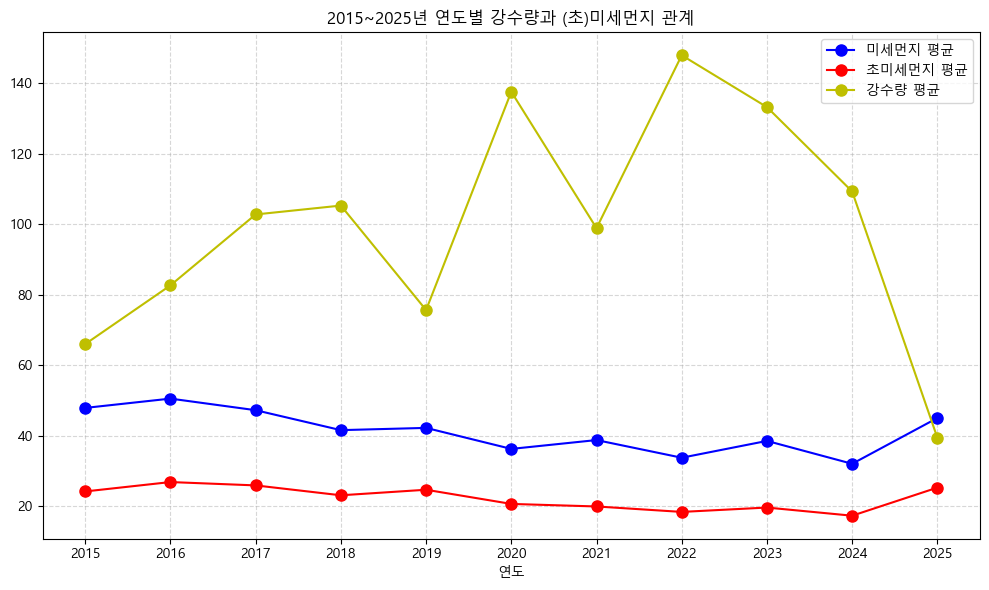

In [35]:
# 1. 연도별 평균을 딕셔너리에서 가져오기
years = [2015 + i for i in range(11)]  # 2015 ~ 2025까지 연도 리스트
pm10_values = [pm10_averages[f"avg{year}_pm10"] for year in years]  # 각 연도별 미세먼지 평균값
pm25_values = [pm25_averages[f"avg{year}_pm25"] for year in years]  # 각 연도별 초미세먼지 평균값
rain_values = [rain_averages[f"avg{year}_rain"] for year in years]  # 각 연도별 강수량 평균값


# 2. 시각화 (선 그래프)
plt.figure(figsize=(10, 6))
plt.plot(years, pm10_values, marker='o', color='b', label="미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, pm25_values, marker='o', color='r', label="초미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, rain_values, marker='o', color='y', label="강수량 평균", linestyle='-', markersize=8)


# 3. 축, 타이틀 설정
plt.xlabel("연도")
plt.title("2015~2025년 연도별 강수량과 (초)미세먼지 관계")
plt.grid(True, axis='both', linestyle='--', alpha=0.5)
plt.xticks(years)  # x축에 연도 표시
plt.legend()


# 4. 그래프 출력
plt.tight_layout()
plt.show()

- 2025년 강수량 데이터가 특히 적어 제외하고도 비교해볼 필요가 있어보임.

In [38]:
corr_matrix = df_years[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)', '강수량(mm)']].corr()

In [40]:
corr_matrix

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥),강수량(mm)
미세먼지(㎍/㎥),1.000000,0.832636,-0.440762
초미세먼지(㎍/㎥),0.832636,1.000000,-0.433211
강수량(mm),-0.440762,-0.433211,1.000000


In [42]:
# 상관관계 계산
corr_pm10 = df_years['미세먼지(㎍/㎥)'].corr(df_years['강수량(mm)'])
corr_pm25 = df_years['초미세먼지(㎍/㎥)'].corr(df_years['강수량(mm)'])

print(f"미세먼지-강수량 상관계수: {corr_pm10:.3f}")
print(f"초미세먼지-강수량 상관계수: {corr_pm25:.3f}")

미세먼지-강수량 상관계수: -0.441
초미세먼지-강수량 상관계수: -0.433


C:\Users\dldbt\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\dldbt\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


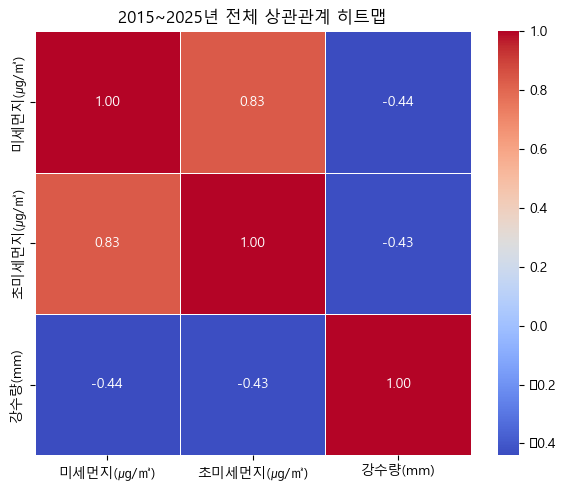

In [44]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("2015~2025년 전체 상관관계 히트맵")
plt.tight_layout()
plt.show()

# 2025년 제외하고 해보기.
- 타 연도에 비해 가지고 있는 개월수가 적기때문에, 결과에 영향을 줄 가능성이 있을듯.
- 2015 ~ 2024년 은 1월 ~ 12월까지 있는 반면, 2025년은 1월 ~ 4월까지의 데이터 밖에 없음.

In [47]:
df_year_non25  =  df_years[(df_years["측정월"] < 202501)]

In [49]:
df_year_non25  

,측정월,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스(ppm),미세먼지(㎍/㎥),초미세먼지(㎍/㎥),강수량(mm)
200,202412,강남구,0.0233,0.0184,0.45,0.0026,32.0,19.0,5.7
201,202412,강남대로,0.0303,0.0111,0.72,0.0035,43.0,20.0,5.7
202,202412,강동구,0.0259,0.0192,0.67,0.0036,38.0,23.0,5.7
203,202412,강변북로,0.0295,0.0147,0.57,0.0033,41.0,21.0,5.7
204,202412,강북구,0.0176,0.0232,0.44,0.0025,32.0,19.0,5.7
...,...,...,...,...,...,...,...,...,...
5674,201501,청계천로,0.0420,0.0100,0.80,0.0090,49.0,28.0,11.3
5675,201501,한강대로,0.0490,0.0070,0.70,0.0060,59.0,26.0,11.3
5676,201501,홍릉로,0.0500,0.0070,0.90,0.0090,54.0,37.0,11.3
5677,201501,홍지문,0.0430,0.0100,0.60,0.0080,50.0,33.0,11.3


In [51]:
corr_matrix = df_year_non25[['미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)', '강수량(mm)']].corr()

In [53]:
corr_matrix

,미세먼지(㎍/㎥),초미세먼지(㎍/㎥),강수량(mm)
미세먼지(㎍/㎥),1.000000,0.833780,-0.442137
초미세먼지(㎍/㎥),0.833780,1.000000,-0.432073
강수량(mm),-0.442137,-0.432073,1.000000


In [55]:
# 상관관계 계산
corr_pm10 = df_year_non25['미세먼지(㎍/㎥)'].corr(df_year_non25['강수량(mm)'])
corr_pm25 = df_year_non25['초미세먼지(㎍/㎥)'].corr(df_year_non25['강수량(mm)'])

print(f"미세먼지-강수량 상관계수: {corr_pm10:.3f}")
print(f"초미세먼지-강수량 상관계수: {corr_pm25:.3f}")

미세먼지-강수량 상관계수: -0.442
초미세먼지-강수량 상관계수: -0.432


- 2025년 데이터를 빼서 해봐도 상관계수에 큰 영향을 주지 않는다.
- 2025년 데이터가 포함되어있는 경우
    - 미세먼지-강수량 상관계수: -0.441
    - 초미세먼지-강수량 상관계수: -0.433

- 포함되지 않은 경우
    - 미세먼지-강수량 상관계수: -0.442
    - 초미세먼지-강수량 상관계수: -0.432

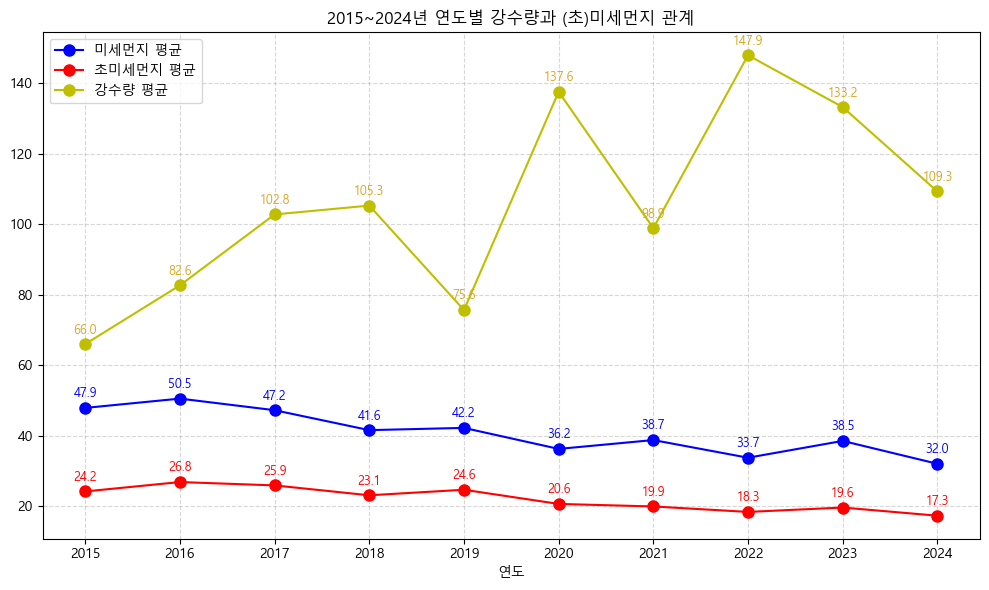

In [58]:
# 1. 연도별 평균을 딕셔너리에서 가져오기
years = [2015 + i for i in range(10)]  # 2015 ~ 2025까지 연도 리스트
pm10_values = [pm10_averages[f"avg{year}_pm10"] for year in years]  # 각 연도별 미세먼지 평균값
pm25_values = [pm25_averages[f"avg{year}_pm25"] for year in years]  # 각 연도별 초미세먼지 평균값
rain_values = [rain_averages[f"avg{year}_rain"] for year in years]  # 각 연도별 강수량 평균값


# 2. 시각화 (선 그래프)
plt.figure(figsize=(10, 6))
plt.plot(years, pm10_values, marker='o', color='b', label="미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, pm25_values, marker='o', color='r', label="초미세먼지 평균", linestyle='-', markersize=8)
plt.plot(years, rain_values, marker='o', color='y', label="강수량 평균", linestyle='-', markersize=8)


# 3. 각 점에 텍스트 표시
# 단위의 규모가 다르기때문에 데이터간의 차이가 커 보일 수 있기때문에 각 x축에 해당하는 y축의 값을 표시해서 확인.
for i, year in enumerate(years):
    plt.text(year, pm10_values[i] + 3, f"{pm10_values[i]:.1f}", color='blue', ha='center', fontsize=9)
    plt.text(year, pm25_values[i] + 3, f"{pm25_values[i]:.1f}", color='red', ha='center', fontsize=9)
    plt.text(year, rain_values[i] + 3, f"{rain_values[i]:.1f}", color='goldenrod', ha='center', fontsize=9)


# 3. 축, 타이틀 설정
plt.xlabel("연도")
plt.title("2015~2024년 연도별 강수량과 (초)미세먼지 관계")
plt.grid(True, axis='both', linestyle='--', alpha=0.5)
plt.xticks(years)  # x축에 연도 표시
plt.legend()


# 4. 그래프 출력
plt.tight_layout()
plt.show()

- 대체로 강수량이 높을수록 미세먼지가 줄어드는 경향이 있다.
- 2015 : 2016의 경우 강수량이 소폭 증가, (초)미세먼지 농도 또한 소폭 증가
- 2016 : 2017의 경우 강수량 소폭 증가, (초)미세먼지 농도 소폭 감소
- 2017 : 2018의 경우 강수량 소폭 증가, (초)미세먼지 농도 소폭 감소
- 2018 : 2019의 경우 강수량 대폭 감소, (초)미세먼지 농도 소폭 증가
- 2019 : 2020의 경우 강수량 대폭 증가, (초)미세먼지 농도 대폭 감소
- 2020 : 2021의 경우 강수량 대폭 감소, 미세먼지 증가, 초미세먼지 농도 감소
- 2021 : 2022의 경우 강수량 대폭 증가, (초)미세먼지 농도 감소
- 2022 : 2023의 경우 강수량 소폭 감소, (초)미세먼지 농도 증가
- 2023: 2024의 경우 강수량 감소, (초)미세먼지 농도 감소

- 2016년의 전년도 대비 강수량 증가와 더불어 초미세먼지와 미세먼지 함께 증가
- 2021년의 전년도 대비 강수량 감소 미세먼지 농도는 증가하였지만, 초미세먼지는 감소
- 2024년의 전년대 대비 강수량 감소와 더불어 (초)미세먼지 함께 감소

무조건적으로 강수량이 높을수록 농도가 낮아지는것도, 강수량이 낮을수록 농도가 높다는 아닌것 같다.

C:\Users\dldbt\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\dldbt\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


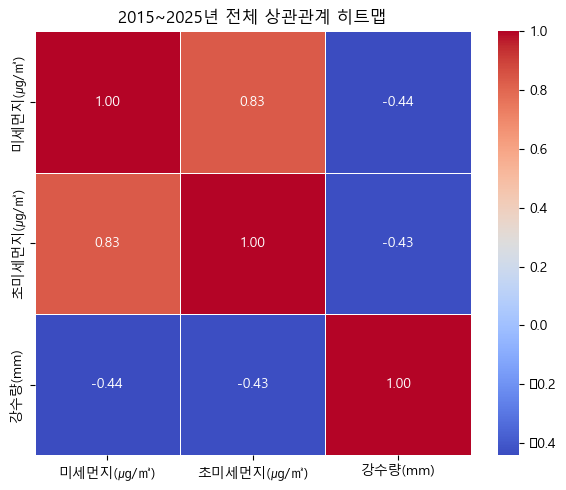

In [62]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("2015~2025년 전체 상관관계 히트맵")
plt.tight_layout()
plt.show()

- 미세먼지와 강수량의 상관관계 계수: -0.44
- 초미세먼지와 강수량의 상관관계 계수: -0.43

- 강수량이 높을수록 미세먼지와 초미세먼지는 감소하는 경향이 조금 있어보임.